# Root 1 Result Analysis

This notebook mirrors the earlier `results/1` submission analysis, but for the root trader run:

- `data/round 1/results/root_1/134796.json`
- `data/round 1/results/root_1/134796.log`

It focuses on three questions:

1. What happened in the live-style result?
2. How did the submitted root trader behave tick by tick?
3. Why did a strategy with only five fills still lose `455` XIRECS?


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from datamodel import Observation, OrderDepth, Trade, TradingState

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 200

RESULT_JSON_PATH = ROOT / "data" / "round 1" / "results" / "root_1" / "134796.json"
RESULT_LOG_PATH = ROOT / "data" / "round 1" / "results" / "root_1" / "134796.log"
TRADER_PATH = ROOT / "src" / "imc_eda" / "round1" / "root" / "root_trader_1.py"

FIGURES_DIR = ROOT / "reports" / "figures" / "round1-root-1-analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def nonzero_frame(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    cleaned = df.copy()
    for column in columns:
        if column in cleaned.columns:
            cleaned[column] = cleaned[column].where(cleaned[column].notna() & (cleaned[column] != 0), np.nan)
    return cleaned


In [2]:
result_json = json.loads(RESULT_JSON_PATH.read_text(encoding="utf-8"))
result_log = json.loads(RESULT_LOG_PATH.read_text(encoding="utf-8"))

activities = pd.read_csv(StringIO(result_json["activitiesLog"]), sep=";").sort_values(["timestamp", "product"]).reset_index(drop=True)
graph = pd.read_csv(StringIO(result_json["graphLog"]), sep=";").rename(columns={"value": "pnl"})
trade_history = pd.DataFrame(result_log["tradeHistory"]).sort_values(["timestamp", "symbol", "price"]).reset_index(drop=True)
submission_trades = trade_history[(trade_history["buyer"] == "SUBMISSION") | (trade_history["seller"] == "SUBMISSION")].copy()
submission_trades["side"] = np.where(submission_trades["buyer"] == "SUBMISSION", "buy", "sell")
submission_trades["signed_qty"] = np.where(submission_trades["buyer"] == "SUBMISSION", submission_trades["quantity"], -submission_trades["quantity"])
submission_trades["cash_flow"] = -submission_trades["signed_qty"] * submission_trades["price"]
submission_trades["cum_position"] = submission_trades["signed_qty"].cumsum()

summary = pd.DataFrame(
    [
        {
            "status": result_json["status"],
            "reported_profit": result_json["profit"],
            "total_market_trades": len(trade_history),
            "submission_trades": len(submission_trades),
            "submission_symbols": ", ".join(sorted(submission_trades["symbol"].unique().tolist())),
            "terminal_position": int(submission_trades["signed_qty"].sum()),
        }
    ]
)
display(summary)
display(submission_trades.groupby("symbol").agg(trades=("symbol", "size"), net_qty=("signed_qty", "sum"), cash=("cash_flow", "sum")).reset_index())
submission_trades


,status,reported_profit,total_market_trades,submission_trades,submission_symbols,terminal_position
0,FINISHED,-455.0,88,5,INTARIAN_PEPPER_ROOT,-20


,symbol,trades,net_qty,cash
0,INTARIAN_PEPPER_ROOT,5,-20,241543.0


,timestamp,buyer,seller,symbol,currency,price,quantity,side,signed_qty,cash_flow,cum_position
47,53200,,SUBMISSION,INTARIAN_PEPPER_ROOT,XIRECS,12059.0,4,sell,-4,48236.0,-4
63,68500,,SUBMISSION,INTARIAN_PEPPER_ROOT,XIRECS,12077.0,5,sell,-5,60385.0,-9
66,71000,,SUBMISSION,INTARIAN_PEPPER_ROOT,XIRECS,12077.0,5,sell,-5,60385.0,-14
72,77000,,SUBMISSION,INTARIAN_PEPPER_ROOT,XIRECS,12083.0,3,sell,-3,36249.0,-17
78,90600,,SUBMISSION,INTARIAN_PEPPER_ROOT,XIRECS,12096.0,3,sell,-3,36288.0,-20


## PnL Path

The run stayed near flat for a long time, then deteriorated after a handful of short pepper sells left the trader short into a rising market.


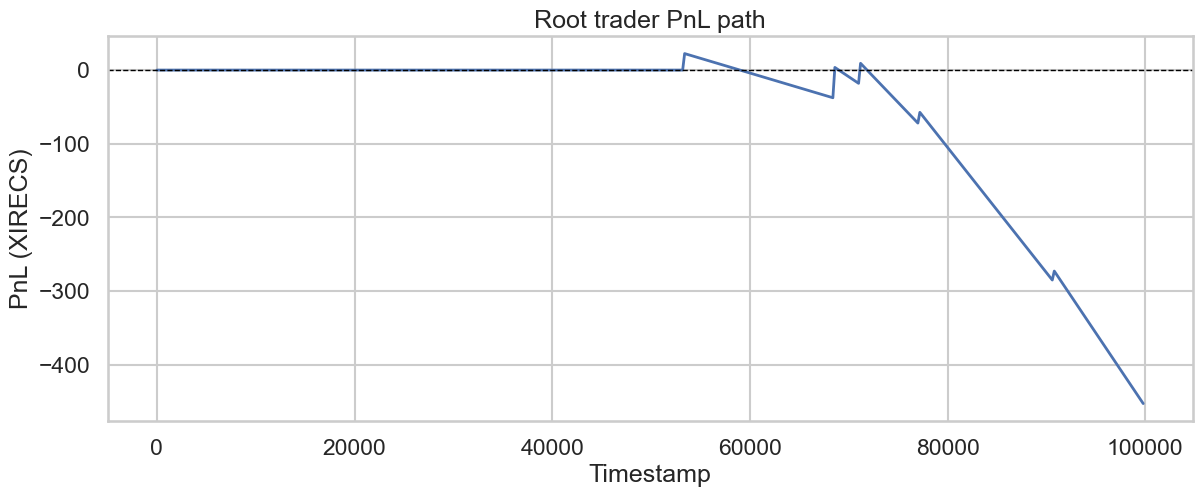

,timestamp,pnl
495,99000,-437.0
496,99200,-441.0
497,99400,-445.0
498,99600,-449.0
499,99800,-453.0


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=graph, x="timestamp", y="pnl", ax=ax, linewidth=2)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Root trader PnL path")
ax.set_xlabel("Timestamp")
ax.set_ylabel("PnL (XIRECS)")
fig.savefig(FIGURES_DIR / "pnl-path.png", dpi=150, bbox_inches="tight")
plt.show()

graph.tail()


## Execution Footprint

Unlike the earlier mixed-product submission, this trader only filled in `INTARIAN_PEPPER_ROOT`, and every fill was a sell. The loss came from ending the session short `20` units rather than from churning many round trips.


,product,side,fills,avg_fill_vs_bid,avg_fill_vs_ask,avg_marked_pnl_at_fill
0,INTARIAN_PEPPER_ROOT,sell,5,13.0,1.0,-82.6375


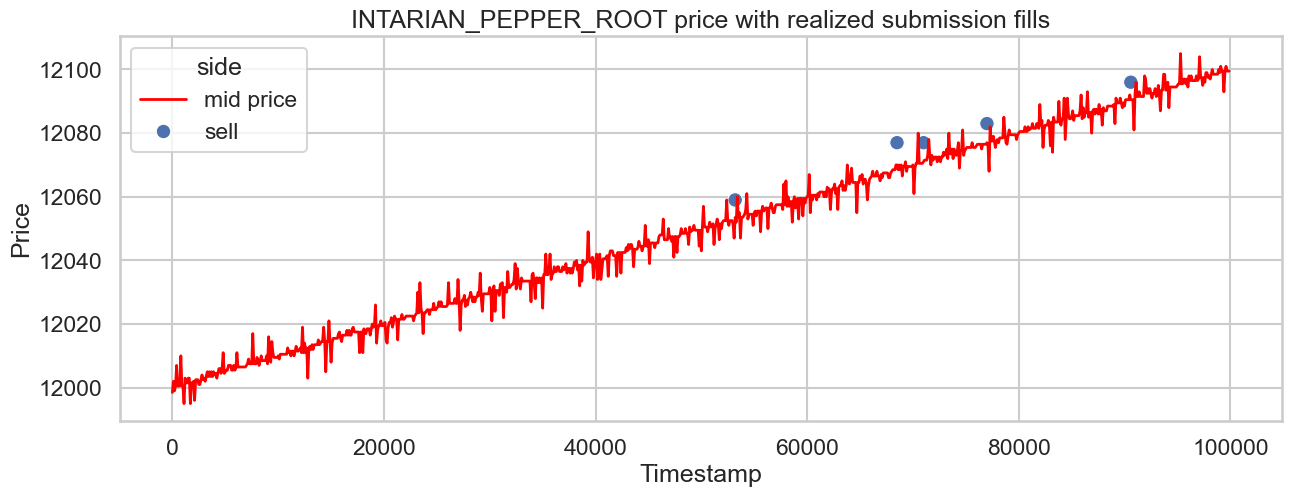

,timestamp,side,price,quantity,bid_price_1,ask_price_1,mid_price,fill_vs_bid,fill_vs_ask,profit_and_loss
0,53200,sell,12059.0,4,12047.0,12060.0,12053.5,12.0,1.0,0.0000
1,68500,sell,12077.0,5,12062.0,12078.0,12070.0,15.0,1.0,-38.0000
2,71000,sell,12077.0,5,12064.0,12078.0,12071.0,13.0,1.0,-18.0000
3,77000,sell,12083.0,3,12070.0,12084.0,12077.0,13.0,1.0,-72.0000
4,90600,sell,12096.0,3,12084.0,12097.0,12090.5,12.0,1.0,-285.1875


In [11]:
quote_columns = ["timestamp", "product", "bid_price_1", "ask_price_1", "mid_price", "profit_and_loss"]
executed = submission_trades.rename(columns={"symbol": "product"}).merge(activities[quote_columns], on=["timestamp", "product"], how="left")
executed["fill_vs_bid"] = executed["price"] - executed["bid_price_1"]
executed["fill_vs_ask"] = executed["ask_price_1"] - executed["price"]
executed["next_mid_change_1"] = executed["mid_price"].shift(-1) - executed["mid_price"]
executed["next_mid_change_5"] = executed["mid_price"].shift(-5) - executed["mid_price"]

display(
    executed.groupby(["product", "side"]).agg(
        fills=("product", "size"),
        avg_fill_vs_bid=("fill_vs_bid", "mean"),
        avg_fill_vs_ask=("fill_vs_ask", "mean"),
        avg_marked_pnl_at_fill=("profit_and_loss", "mean"),
    ).round(4).reset_index()
)

pepper_quotes = activities[activities["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper_quotes_plot = nonzero_frame(pepper_quotes, ["bid_price_1", "ask_price_1", "mid_price"])
executed_plot = nonzero_frame(executed, ["price", "bid_price_1", "ask_price_1", "mid_price"])
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=pepper_quotes_plot, x="timestamp", y="mid_price", ax=ax, label="mid price", linewidth=2, color="red")
sns.scatterplot(data=executed_plot, x="timestamp", y="price", hue="side", style="side", s=110, ax=ax)
ax.set_title("INTARIAN_PEPPER_ROOT price with realized submission fills")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
fig.savefig(FIGURES_DIR / "pepper-fills.png", dpi=150, bbox_inches="tight")
plt.show()

executed[["timestamp", "side", "price", "quantity", "bid_price_1", "ask_price_1", "mid_price", "fill_vs_bid", "fill_vs_ask", "profit_and_loss"]]


## Inventory Risk

Because the fills were all sells, the main risk was inventory accumulation. Once the trader built a short, subsequent price rises translated directly into mark-to-market losses.


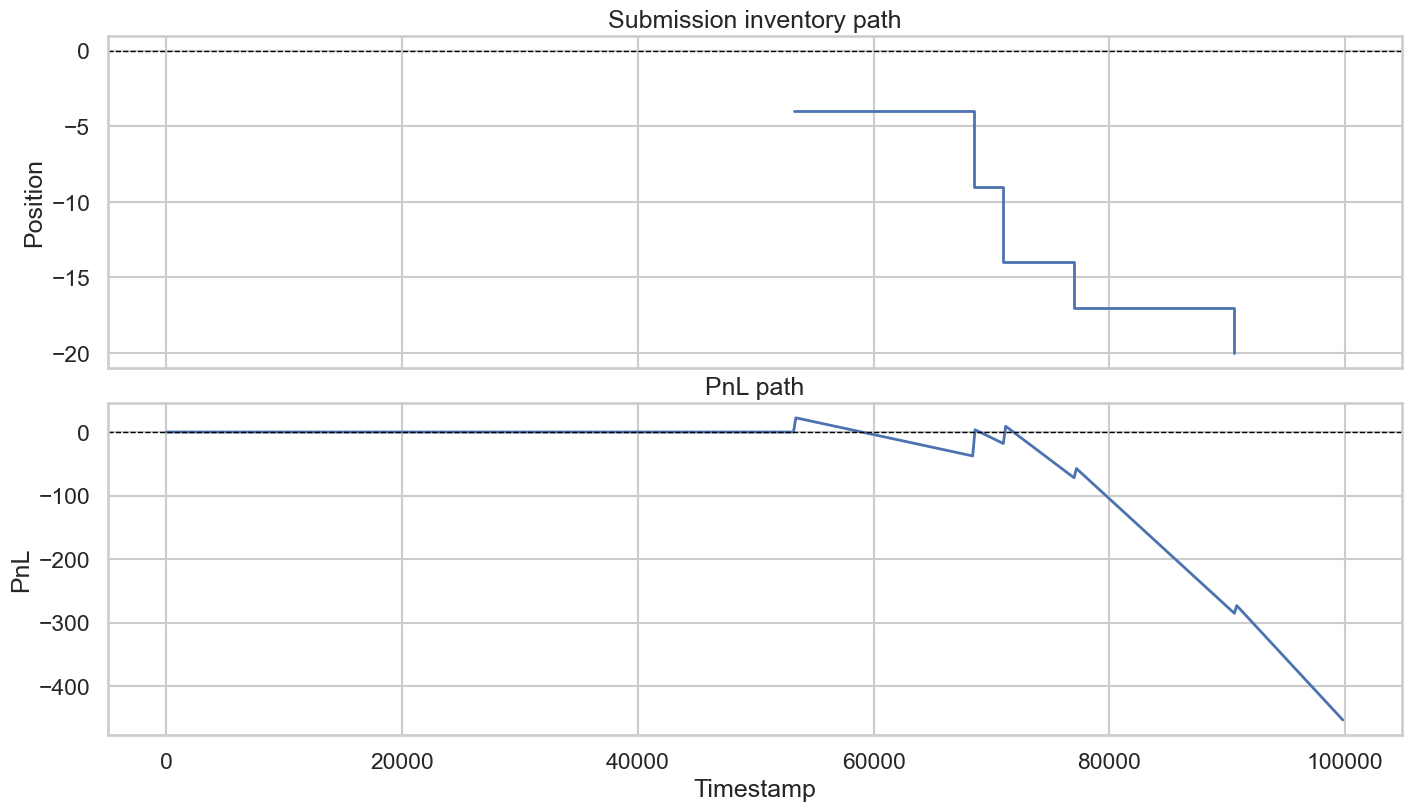

,timestamp,signed_qty,position
0,53200,-4,-4
1,68500,-5,-9
2,71000,-5,-14
3,77000,-3,-17
4,90600,-3,-20


In [5]:
inventory_path = executed[["timestamp", "signed_qty"]].copy()
inventory_path["position"] = inventory_path["signed_qty"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
sns.stepplot = getattr(sns, "stepplot", None)

axes[0].step(inventory_path["timestamp"], inventory_path["position"], where="post", linewidth=2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Submission inventory path")
axes[0].set_ylabel("Position")

sns.lineplot(data=graph, x="timestamp", y="pnl", ax=axes[1], linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("PnL path")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("PnL")

fig.savefig(FIGURES_DIR / "inventory-and-pnl.png", dpi=150, bbox_inches="tight")
plt.show()

inventory_path


## Replay The Submitted Root Trader

The root trader stores useful internal diagnostics in `traderData`, so replaying it lets us inspect:

- estimated fair value
- residual versus threshold
- signal direction
- buy/sell miss counters and aggression levels
- how often it tried to quote versus how often it actually filled


In [6]:
spec = importlib.util.spec_from_file_location("root_submission_trader_module", TRADER_PATH)
submission_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(submission_module)
Trader = submission_module.Trader

replay_trader = Trader()
trader_data = ""
replayed_rows = []

submission_trade_rows = submission_trades.to_dict("records")
own_trades_by_ts = {}
position_by_ts = {}
running_position = 0
for ts in sorted(activities["timestamp"].unique().tolist()):
    fills_this_ts = []
    for row in submission_trade_rows:
        if row["timestamp"] != ts:
            continue
        fills_this_ts.append(
            Trade(
                symbol=row["symbol"],
                price=int(row["price"]),
                quantity=int(row["quantity"]),
                buyer=row["buyer"],
                seller=row["seller"],
                timestamp=int(row["timestamp"]),
            )
        )
        running_position += int(row["signed_qty"])
    own_trades_by_ts[ts] = {"INTARIAN_PEPPER_ROOT": fills_this_ts} if fills_this_ts else {}
    position_by_ts[ts] = {"INTARIAN_PEPPER_ROOT": running_position} if running_position else {}

for ts, group in activities.groupby("timestamp", sort=True):
    order_depths = {}
    mid_price = np.nan
    for row in group.itertuples(index=False):
        depth = OrderDepth()
        for level in (1, 2, 3):
            bid_price = getattr(row, f"bid_price_{level}", np.nan)
            bid_volume = getattr(row, f"bid_volume_{level}", np.nan)
            ask_price = getattr(row, f"ask_price_{level}", np.nan)
            ask_volume = getattr(row, f"ask_volume_{level}", np.nan)
            if pd.notna(bid_price) and pd.notna(bid_volume):
                depth.buy_orders[int(bid_price)] = int(bid_volume)
            if pd.notna(ask_price) and pd.notna(ask_volume):
                depth.sell_orders[int(ask_price)] = -int(ask_volume)
        order_depths[row.product] = depth
        if row.product == "INTARIAN_PEPPER_ROOT":
            mid_price = row.mid_price

    state = TradingState(
        trader_data,
        int(ts),
        {},
        order_depths,
        own_trades_by_ts.get(ts, {}),
        {},
        position_by_ts.get(ts, {}),
        Observation({}, {}),
    )
    orders_by_product, _, trader_data = replay_trader.run(state)
    memory = json.loads(trader_data)
    pepper = memory.get("pepper", {})
    orders = orders_by_product.get("INTARIAN_PEPPER_ROOT", [])

    replayed_rows.append(
        {
            "timestamp": int(ts),
            "mid_price": mid_price,
            "signal": pepper.get("last_signal", 0),
            "sigma": pepper.get("last_sigma"),
            "residual": pepper.get("last_residual"),
            "adjusted_residual": pepper.get("last_adjusted_residual"),
            "fair_value": pepper.get("last_fair_value"),
            "buy_aggression_level": pepper.get("buy_aggression_level", 0),
            "sell_aggression_level": pepper.get("sell_aggression_level", 0),
            "buy_miss_count": pepper.get("buy_miss_count", 0),
            "sell_miss_count": pepper.get("sell_miss_count", 0),
            "position": position_by_ts.get(ts, {}).get("INTARIAN_PEPPER_ROOT", 0),
            "order_count": len(orders),
            "buy_orders": sum(1 for order in orders if order.quantity > 0),
            "sell_orders": sum(1 for order in orders if order.quantity < 0),
            "submitted_prices": [order.price for order in orders],
            "submitted_quantities": [order.quantity for order in orders],
        }
    )

replayed = pd.DataFrame(replayed_rows)
replay_summary = pd.DataFrame(
    [
        {
            "ticks": len(replayed),
            "ticks_with_orders": int((replayed["order_count"] > 0).sum()),
            "submitted_orders": int(replayed["order_count"].sum()),
            "buy_signal_share": float((replayed["signal"] > 0).mean()),
            "sell_signal_share": float((replayed["signal"] < 0).mean()),
            "realized_fills": len(submission_trades),
            "fill_per_submitted_order": float(len(submission_trades) / replayed["order_count"].sum()),
            "max_short_position": int(replayed["position"].min()),
        }
    ]
).round(4)

display(replay_summary)
display(replayed[replayed["order_count"] > 0].head(15))


,ticks,ticks_with_orders,submitted_orders,buy_signal_share,sell_signal_share,realized_fills,fill_per_submitted_order,max_short_position
0,1000,457,457,0.092,0.505,5,0.0109,-20


,timestamp,mid_price,signal,sigma,residual,adjusted_residual,fair_value,buy_aggression_level,sell_aggression_level,buy_miss_count,sell_miss_count,position,order_count,buy_orders,sell_orders,submitted_prices,submitted_quantities
25,2500,12001.0,1,1.000000,-1.638528,-1.638528,12002.638528,0,0,0,0,0,1,1,0,[11993],[5]
26,2600,12001.0,1,1.000000,-1.468379,-1.468379,12002.468379,1,0,1,0,0,1,1,0,[11994],[5]
42,4200,12003.0,1,1.000000,-1.560729,-1.560729,12004.560729,1,0,2,0,0,1,1,0,[11996],[5]
59,5900,12005.5,1,1.000000,-1.181707,-1.181707,12006.681707,1,0,3,0,0,1,1,0,[12000],[5]
61,6100,12011.0,-1,1.096877,3.761585,3.761585,12007.238415,1,0,4,0,0,1,0,1,[12013],[-5]
82,8200,12007.0,1,1.075800,-1.284146,-1.284146,12008.284146,1,1,4,1,0,1,1,0,[12000],[5]
90,9000,12007.5,1,1.000000,-1.372561,-1.372561,12008.872561,1,1,5,1,0,1,1,0,[12000],[5]
93,9300,12008.0,1,1.000000,-0.923171,-0.923171,12008.923171,1,1,6,1,0,1,1,0,[12001],[5]
94,9400,12014.5,-1,1.279514,5.002439,5.002439,12009.497561,1,1,7,1,0,1,0,1,[12015],[-5]
101,10100,12009.0,1,1.280265,-1.106098,-1.106098,12010.106098,1,1,7,2,0,1,1,0,[12002],[5]


## Signal And Fair-Value Diagnostics

This strategy is a residual trader: it estimates a linear fair value, compares the current mid to that fair value, and acts once the residual is large relative to rolling sigma. The visual below shows when that model was pushing for buys or sells.


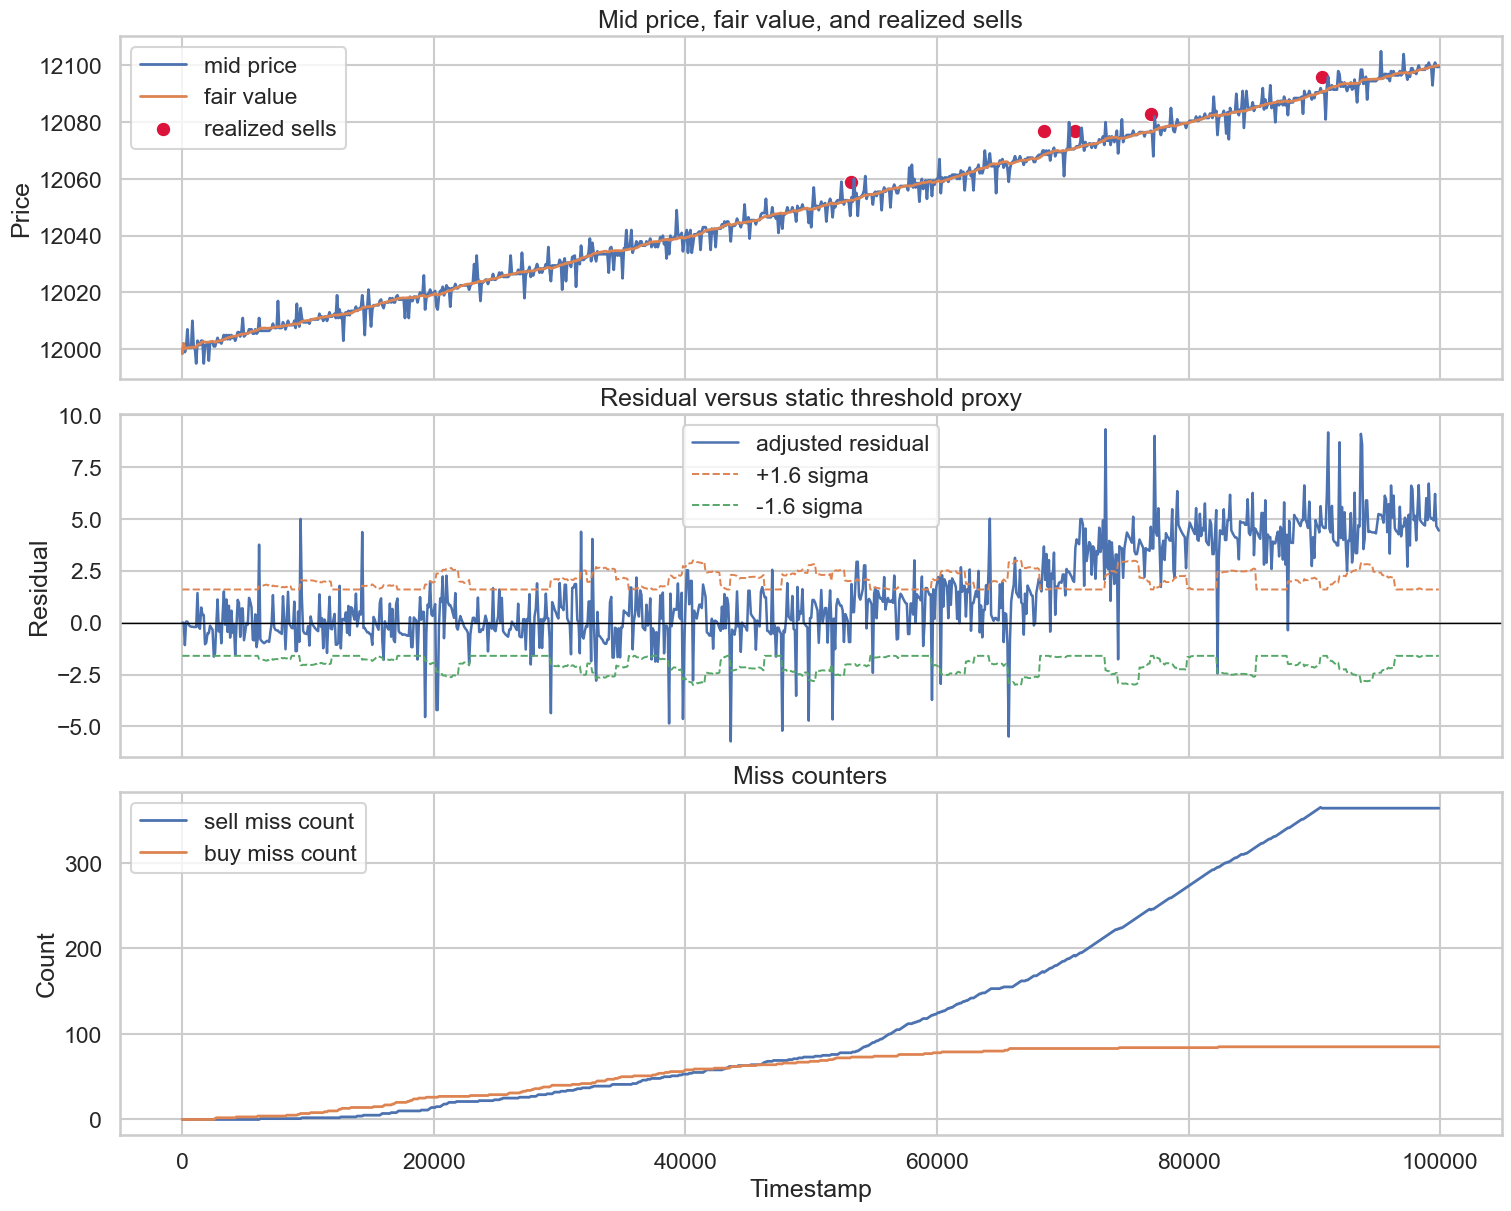

In [7]:
replayed["upper_threshold"] = 1.6 * replayed["sigma"]
replayed["lower_threshold"] = -1.6 * replayed["sigma"]
replayed_plot = nonzero_frame(replayed, ["mid_price", "fair_value"])
sell_points_plot = nonzero_frame(executed[executed["side"] == "sell"], ["price"])

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, constrained_layout=True)

sns.lineplot(data=replayed_plot, x="timestamp", y="mid_price", ax=axes[0], label="mid price", linewidth=2)
sns.lineplot(data=replayed_plot, x="timestamp", y="fair_value", ax=axes[0], label="fair value", linewidth=2)
if not sell_points_plot.empty:
    sns.scatterplot(data=sell_points_plot, x="timestamp", y="price", color="crimson", s=110, ax=axes[0], label="realized sells")
axes[0].set_title("Mid price, fair value, and realized sells")
axes[0].set_ylabel("Price")

sns.lineplot(data=replayed, x="timestamp", y="adjusted_residual", ax=axes[1], linewidth=1.8, label="adjusted residual")
sns.lineplot(data=replayed, x="timestamp", y="upper_threshold", ax=axes[1], linestyle="--", linewidth=1.4, label="+1.6 sigma")
sns.lineplot(data=replayed, x="timestamp", y="lower_threshold", ax=axes[1], linestyle="--", linewidth=1.4, label="-1.6 sigma")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residual versus static threshold proxy")
axes[1].set_ylabel("Residual")

sns.lineplot(data=replayed, x="timestamp", y="sell_miss_count", ax=axes[2], label="sell miss count", linewidth=2)
sns.lineplot(data=replayed, x="timestamp", y="buy_miss_count", ax=axes[2], label="buy miss count", linewidth=2)
axes[2].set_title("Miss counters")
axes[2].set_xlabel("Timestamp")
axes[2].set_ylabel("Count")

fig.savefig(FIGURES_DIR / "signal-diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


## Did Fills Help Or Hurt?

With only five fills, we can inspect each one directly and see whether the market moved in the trader's favor afterward.


,timestamp,side,price,quantity,mid_price,mid_change_1,mtm_pnl_1,mid_change_5,mtm_pnl_5,mid_change_10,mtm_pnl_10,mid_change_20,mtm_pnl_20
0,53200,sell,12059.0,4,12053.5,-1.5,-6.0,-6.5,-26.0,2.5,10.0,0.5,2.0
1,68500,sell,12077.0,5,12070.0,-1.5,-7.5,-3.5,-17.5,-0.5,-2.5,10.0,50.0
2,71000,sell,12077.0,5,12071.0,0.5,2.5,7.0,35.0,1.0,5.0,2.0,10.0
3,77000,sell,12083.0,3,12077.0,-1.0,-3.0,0.5,1.5,1.0,3.0,2.0,6.0
4,90600,sell,12096.0,3,12090.5,0.0,0.0,5.5,16.5,1.0,3.0,0.5,1.5


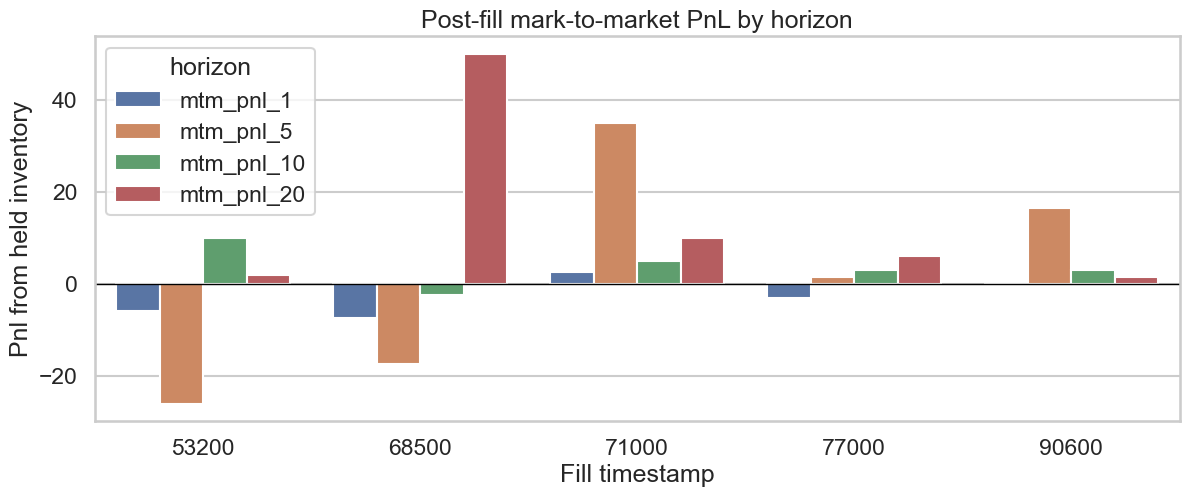

In [8]:
pepper_path = pepper_quotes[["timestamp", "mid_price"]].copy().reset_index(drop=True)
timestamp_to_index = {timestamp: index for index, timestamp in enumerate(pepper_path["timestamp"])}

rows = []
for row in executed.itertuples(index=False):
    idx = timestamp_to_index[row.timestamp]
    entry = {
        "timestamp": row.timestamp,
        "side": row.side,
        "price": row.price,
        "quantity": row.quantity,
        "mid_price": row.mid_price,
    }
    for horizon in (1, 5, 10, 20):
        future_idx = min(idx + horizon, len(pepper_path) - 1)
        future_mid = float(pepper_path.iloc[future_idx]["mid_price"])
        move = future_mid - row.mid_price
        entry[f"mid_change_{horizon}"] = move
        entry[f"mtm_pnl_{horizon}"] = -row.signed_qty * move
    rows.append(entry)

post_fill = pd.DataFrame(rows)
display(post_fill.round(4))

plot_post_fill = post_fill.melt(
    id_vars=["timestamp", "side", "price", "quantity"],
    value_vars=["mtm_pnl_1", "mtm_pnl_5", "mtm_pnl_10", "mtm_pnl_20"],
    var_name="horizon",
    value_name="mtm_pnl",
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_post_fill, x="timestamp", y="mtm_pnl", hue="horizon", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Post-fill mark-to-market PnL by horizon")
ax.set_xlabel("Fill timestamp")
ax.set_ylabel("Pnl from held inventory")
fig.savefig(FIGURES_DIR / "post-fill-pnl.png", dpi=150, bbox_inches="tight")
plt.show()


## What Stands Out

The failure here is simpler than the earlier `results/1` story. This was not about a dead product leg. It was about sparse fills, one-sided inventory, and a market that kept rising after the trader sold into it.


In [9]:
findings = [
    "1. The run finished with only five submission fills, all sells in `INTARIAN_PEPPER_ROOT`.",
    "2. Those five fills built a terminal short position of `20`, so most of the loss came from holding inventory rather than from many losing round trips.",
    "3. Realized sells were consistently near the best ask, usually one tick below it, which suggests the trader was pricing passively rather than crossing aggressively.",
    "4. The replay shows many more order attempts than fills, so the strategy's realized edge was dominated by fill scarcity and timing risk.",
    "5. Once short inventory existed, continued upward drift in pepper prices translated directly into negative marked PnL.",
    "6. The trader's miss counters climbed over time, which means the logic was increasingly trying to tighten after unfilled orders, but that adaptation was not enough to prevent a bad short accumulation.",
]

display(Markdown("\n".join(f"- {item}" for item in findings)))


- 1. The run finished with only five submission fills, all sells in `INTARIAN_PEPPER_ROOT`.
- 2. Those five fills built a terminal short position of `20`, so most of the loss came from holding inventory rather than from many losing round trips.
- 3. Realized sells were consistently near the best ask, usually one tick below it, which suggests the trader was pricing passively rather than crossing aggressively.
- 4. The replay shows many more order attempts than fills, so the strategy's realized edge was dominated by fill scarcity and timing risk.
- 5. Once short inventory existed, continued upward drift in pepper prices translated directly into negative marked PnL.
- 6. The trader's miss counters climbed over time, which means the logic was increasingly trying to tighten after unfilled orders, but that adaptation was not enough to prevent a bad short accumulation.

## Bottom Line

`results/root_1` was a low-activity but still expensive run. The trader did generate signals and submit orders, but only five sells actually filled. Those fills accumulated a short position, and the remaining session marked that short against a firmer pepper market, producing the final loss of roughly `-455`.
